In [1]:
!apt-get update
!apt-get install -y xvfb python-opengl ffmpeg
!pip install gym pyvirtualdisplay

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [61.3 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [1,969 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-update

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl (166.0 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-m

/usr/local/lib/python3.10/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). 

Episode: 0, Total Reward: 58.0, Epsilon: 0.995


/usr/local/lib/python3.10/dist-packages/gym/envs/classic_control/cartpole.py:179: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Episode: 100, Total Reward: 11.0, Epsilon: 0.6027415843082742
Episode: 200, Total Reward: 22.0, Epsilon: 0.36512303261753626
Episode: 300, Total Reward: 0.0, Epsilon: 0.2211807388415433
Episode: 400, Total Reward: 6.0, Epsilon: 0.13398475271138335
Episode: 500, Total Reward: 4.0, Epsilon: 0.0811640021330769
Episode: 600, Total Reward: 1.0, Epsilon: 0.04916675299948831
Episode: 700, Total Reward: 26.0, Epsilon: 0.029783765425331846
Episode: 800, Total Reward: 2.0, Epsilon: 0.018042124582040707
Episode: 900, Total Reward: 0.0, Epsilon: 0.010929385683282892
Episode: 1000, Total Reward: 10.0, Epsilon: 0.01
Episode: 1100, Total Reward: 34.0, Epsilon: 0.01
Episode: 1200, Total Reward: 2.0, Epsilon: 0.01
Episode: 1300, Total Reward: 6.0, Epsilon: 0.01
Episode: 1400, Total Reward: 1.0, Epsilon: 0.01
Episode: 1500, Total Reward: 3.0, Epsilon: 0.01
Episode: 1600, Total Reward: 3.0, Epsilon: 0.01
Episode: 1700, Total Reward: 7.0, Epsilon: 0.01
Episode: 1800, Total Reward: 3.0, Epsilon: 0.01
Episo

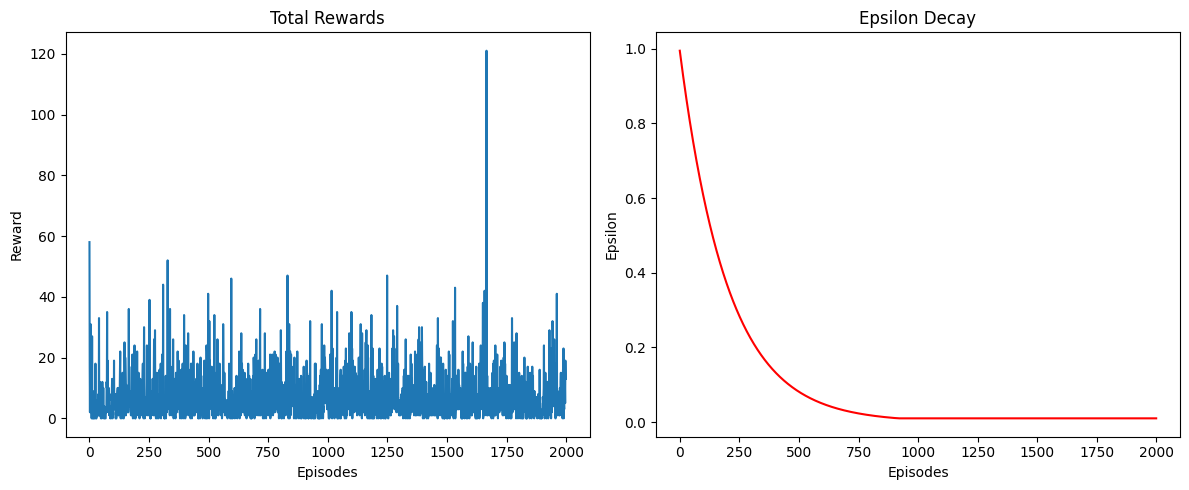

In [3]:

# Step 1: Install necessary libraries if not already present
!pip install torch torchvision gym matplotlib

# Step 2: Import the libraries
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

# Step 3: Define the neural network architecture
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = self.fc1(state)
        x = self.relu(x)
        return self.fc2(x)

# Step 4: Initialize the environment
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# Step 5: Initialize the Q-network
q_network = QNetwork(state_size, action_size)
optimizer = optim.Adam(q_network.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Step 6: Set up hyperparameters
gamma = 0.99  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
num_episodes = 2000
batch_size = 64
memory = deque(maxlen=2000)

# Step 7: Define the training loop
def train_q_network(epsilon, epsilon_decay, epsilon_min, num_episodes):
    global memory  #
    total_rewards = []
    epsilon_values = []

    for episode in range(num_episodes):
        state = env.reset()
        state = torch.from_numpy(state).float().unsqueeze(0)
        total_reward = 0
        done = False

        while not done:
            # Epsilon-greedy action selection
            if np.random.rand() <= epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q_values = q_network(state)
                    action = q_values.max(1)[1].item()

            # Take the action
            next_state, reward, done, _ = env.step(action)
            next_state = torch.from_numpy(next_state).float().unsqueeze(0)

            # Save in memory
            memory.append((state, action, reward, next_state, done))

            # Learn every time step
            if len(memory) > batch_size:
                minibatch = random.sample(memory, batch_size)
                for state, action, reward, next_state, done in minibatch:
                    target = reward + (1 - done) * gamma * q_network(next_state).max(1)[0]
                    current_q = q_network(state)[0][action]
                    loss = criterion(current_q, target)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            state = next_state
            total_reward += reward

        # Decay exploration rate
        epsilon = max(epsilon_min, epsilon_decay * epsilon)
        total_rewards.append(total_reward)
        epsilon_values.append(epsilon)

        if episode % 100 == 0:  # Print every 100 episodes
            print(f'Episode: {episode}, Total Reward: {total_reward}, Epsilon: {epsilon}')

    return total_rewards, epsilon_values

# Step 8: Run the training and collect data
total_rewards, epsilon_values = train_q_network(epsilon, epsilon_decay, epsilon_min, num_episodes)

# Step 9: Plot the training results
plt.figure(figsize=(12, 5))

# Plot Total Rewards
plt.subplot(1, 2, 1)
plt.plot(total_rewards)
plt.title('Total Rewards')
plt.xlabel('Episodes')
plt.ylabel('Reward')

# Plot Epsilon Values
plt.subplot(1, 2, 2)
plt.plot(epsilon_values, color='r')
plt.title('Epsilon Decay')
plt.xlabel('Episodes')
plt.ylabel('Epsilon')

plt.tight_layout()
plt.show()